### 서울시 행정동별 요양시설 유효공급 격차 ① 공간 준비

본 노트북은 '초고령 사회, 서울의 의료·돌봄 인프라는 어디에 더 필요한가?'의 행정동 단위 E2SFCA 분석에 쓸 공간 자료를 준비한다. 행정동 경계와 중심점, 행정동별 5세 연령군 인구, 입소시설 좌표를 만들고 `outputs/`에 캐시한다.

### 1. 분석 기준

- 행정동 경계: vuski/admdongkor `ver20240701` (2024-07-01 기준, 행정안전부 행정동 코드 `adm_cd2`)
- 인구: 행정안전부 주민등록 인구통계(2024-07-31), 전체 읍면동, 5세 연령군·성별
- 시설: 국민건강보험공단 장기요양기관 시설별 현황(2024-07-16), 입소시설 A01~A05 (기존 자치구 분석과 동일)
- 좌표계: EPSG:5179, 동 대표점은 경계 다각형의 중심점(centroid)
- 분석 범위: 서울·경기·인천의 모든 행정동(읍면동)과 입소시설. 결과 보고는 서울 동만 한다.

서울 경계 근처 동은 경계 밖 시설도 이용하고, 경계 근처 시설은 경계 밖 수요와도 나눠 쓴다. 서울만 잘라서 계산하면 이 두 효과가 빠져 경계 근처 동의 공급이 과대·과소평가되므로 버퍼 지역을 계산에 포함한다.

E2SFCA는 두 단계로 계산되므로 서울 동의 접근성 A_i는 d0 안의 시설 공급비 R_j로 정해지고, R_j는 다시 그 시설에서 d0 안의 수요로 정해진다. 따라서 서울 경계에서 최대 반경의 두 배(민감도 최대 15km → 30km)까지 수요와 공급이 빠짐없이 있어야 한다. 경기·인천 전체를 분석 범위로 두고, 범위 밖 육지(강원·충북·충남)가 서울 경계에서 30km보다 멀다는 것을 assert로 확인한다. 서해 쪽은 바다라 수요가 없다.

In [1]:
from io import BytesIO
import json
import os
import re
import time
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import display, Markdown

import config as C

pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.rcParams["font.family"] = ["AppleGothic", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

C.ASSET_DIR.mkdir(exist_ok=True)
C.OUTPUT_DIR.mkdir(exist_ok=True)

### 2. 행정동 경계

경계 파일(약 35MB)은 처음 실행할 때만 내려받아 `assets/`에 저장한다. 서울·인천·경기 행정동만 남기고 EPSG:5179로 변환한 뒤 중심점을 계산한다.

In [2]:
boundary_file = C.ASSET_DIR / f"HangJeongDong_{C.ADM_BOUNDARY_VERSION}.geojson"
if not boundary_file.exists():
    r = requests.get(C.ADM_BOUNDARY_URL, timeout=300)
    r.raise_for_status()
    boundary_file.write_bytes(r.content)

dong = gpd.read_file(boundary_file)
dong = dong.loc[dong["sido"].isin(C.SIDO_CODES)].to_crs(C.CRS)
dong = dong.rename(columns={"adm_cd2": "행정동코드", "adm_nm": "행정동명", "sidonm": "시도", "sggnm": "시군구"})
dong = dong[["행정동코드", "행정동명", "시도", "시군구", "geometry"]].reset_index(drop=True)
dong["구코드"] = dong["행정동코드"].str[:5]
centroid = dong.geometry.centroid
dong["cx"], dong["cy"] = centroid.x, centroid.y

assert dong["행정동코드"].is_unique
dong.groupby("시도").size().rename("행정동 수").to_frame()

,행정동 수
시도,
경기도,601
서울특별시,426
인천광역시,156


### 3. 행정동별 5세 연령군 인구

기존 노트북과 같은 행정안전부 다운로드 엔드포인트를 쓰되, 다운로드 범위를 '전체읍면동현황'(`xlsStats=3`)으로, 연령 구분을 5세 단위(`sltArgTypes=5`)로 바꾼다. 인구 범위도 기존과 같이 거주자+거주불명자+재외국민(외국인 제외)이다. 응답은 시도·시군구·읍면동 행이 섞여 있으므로 10자리 행정구역 코드로 수준을 구분한다.

In [3]:
year, month = C.POPULATION_YEAR_MONTH
population_file = C.ASSET_DIR / f"행정안전부_읍면동_5세연령별_주민등록인구_{year}{month}.csv"

if not population_file.exists():
    payload = {
        "sltOrgType": "1",
        "sltOrgLvl1": "A",
        "sltOrgLvl2": "",
        "gender": "gender",
        "sum": "sum",
        "sltUndefType": "",  # 전체: 거주자+거주불명자+재외국민, 외국인 제외
        "searchYearStart": year,
        "searchMonthStart": month,
        "searchYearEnd": year,
        "searchMonthEnd": month,
        "sltOrderType": "1",
        "sltOrderValue": "ASC",
        "sltArgTypes": "5",
        "sltArgTypeA": "0",
        "sltArgTypeB": "100",
        "category": "month",
    }
    session = requests.Session()
    session.get("https://jumin.mois.go.kr/ageStatMonth.do", timeout=30).raise_for_status()
    response = session.post(
        "https://jumin.mois.go.kr/downloadCsvAge.do?searchYearMonth=month&xlsStats=3",
        data=payload, timeout=600,
    )
    response.raise_for_status()
    population_file.write_bytes(response.content)

pop_raw = pd.read_csv(population_file, encoding="cp949", dtype=str)
pop_raw["코드"] = pop_raw["행정구역"].str.extract(r"\((\d{10})\)")[0]
pop_raw["이름"] = pop_raw["행정구역"].str.replace(r"\s*\(\d{10}\)", "", regex=True).str.strip()
pop_raw = pop_raw.loc[pop_raw["코드"].str[:2].isin(C.SIDO_CODES)]

# 넓은 표를 (코드, 성별, 연령) 긴 표로 바꾼다. 연령은 5세 구간의 시작 나이다.
age_cols = [c for c in pop_raw.columns if re.match(rf"{year}년{month}월_[남여]_\d+", c)]
pop_long = pop_raw.melt(id_vars=["코드", "이름"], value_vars=age_cols, var_name="열", value_name="인구")
pop_long["성별"] = pop_long["열"].str.extract(r"_([남여])_")[0]
pop_long["연령"] = pop_long["열"].str.extract(r"_(\d+)(?:~|세)")[0].astype(int)
pop_long["인구"] = pd.to_numeric(pop_long["인구"].str.replace(",", "", regex=False))
pop_long = pop_long.drop(columns="열")

is_dong = pop_long["코드"].str[5:] != "00000"
is_sgg = ~is_dong & (pop_long["코드"].str[2:5] != "000")
pop_dong = pop_long.loc[is_dong].copy()
pop_sgg = pop_long.loc[is_sgg].copy()

# 시군구 합계(계 열)와 성별×연령 합이 같은지 먼저 확인한다.
total_col = f"{year}년{month}월_계_총인구수"
reported_total = pd.to_numeric(pop_raw.set_index("코드")[total_col].str.replace(",", "", regex=False))
assert (pop_long.groupby("코드")["인구"].sum() == reported_total.loc[pop_long["코드"].unique()]).all()
print(f"읍면동 {pop_dong['코드'].nunique():,}개, 시군구 {pop_sgg['코드'].nunique():,}개")

읍면동 1,189개, 시군구 95개


### 4. 경계와 인구의 행정동 코드 대응

경계와 인구 자료를 10자리 행정동 코드로 맞춘다. 인구 자료에만 있는 코드는 행정동이 아니라 읍·면의 출장소이며, 경계 자료에서는 모(母) 읍·면 다각형에 포함되어 있다. 출장소 인구는 이름이 출장소 이름의 앞부분과 같은 같은 시군구의 읍·면에 더한다(예: 화도읍동부출장소 → 화도읍).

In [4]:
dong_names = pop_raw.set_index("코드")["이름"]
only_pop = sorted(set(pop_dong["코드"]) - set(dong["행정동코드"]))
only_boundary = sorted(set(dong["행정동코드"]) - set(pop_dong["코드"]))

branch_map = {}
for code_ in only_pop:
    short = dong_names[code_].split()[-1]
    parents = dong.loc[
        dong["구코드"].eq(code_[:5]) & dong["행정동명"].str.split().str[-1].map(lambda n: short.startswith(n))
    ]
    assert len(parents) == 1, f"모 읍면을 찾지 못함: {dong_names[code_]}"
    branch_map[code_] = parents["행정동코드"].item()

branch_table = pd.DataFrame({
    "출장소": [dong_names[c] for c in branch_map],
    "출장소코드": list(branch_map),
    "합산 대상": [dong.set_index("행정동코드").loc[p, "행정동명"] for p in branch_map.values()],
    "인구": [pop_dong.loc[pop_dong["코드"].eq(c), "인구"].sum() for c in branch_map],
})
pop_dong["행정동코드"] = pop_dong["코드"].replace(branch_map)

seoul_boundary = dong.loc[dong["시도"].eq("서울특별시"), "행정동코드"]
seoul_pop = pop_dong.loc[pop_dong["행정동코드"].str[:2].eq("11"), "행정동코드"].unique()
assert len(only_boundary) == 0
assert set(seoul_boundary) == set(seoul_pop) and seoul_boundary.nunique() == 426
assert not any(c.startswith("11") for c in only_pop)

display(Markdown(
    f"- 서울 행정동: 경계 **{seoul_boundary.nunique()}개**, 인구 **{len(seoul_pop)}개**로 1:1 대응한다.\n"
    f"- 인구 자료에만 있는 코드 {len(only_pop)}개는 모두 경기·인천 출장소이며 모 읍·면에 합산한다."
))
display(branch_table.style.format({"인구": "{:,.0f}"}).hide(axis="index"))

- 서울 행정동: 경계 **426개**, 인구 **426개**로 1:1 대응한다.
- 인구 자료에만 있는 코드 6개는 모두 경기·인천 출장소이며 모 읍·면에 합산한다.

출장소,출장소코드,합산 대상,인구
인천광역시 강화군 서도면볼음출장소,2871042500,인천광역시 강화군 서도면,270
인천광역시 옹진군 북도면장봉출장소,2872031500,인천광역시 옹진군 북도면,963
인천광역시 옹진군 대청면소청출장소,2872034500,인천광역시 옹진군 대청면,230
인천광역시 옹진군 자월면이작출장소,2872037500,인천광역시 옹진군 자월면,374
경기도 남양주시 화도읍동부출장소,4136025700,경기도 남양주시 화도읍,"13,243"
경기도 남양주시 화도읍남부출장소,4136025800,경기도 남양주시 화도읍,"35,612"


In [5]:
# 동별 인구를 구별로 합하면 행정안전부 시군구 인구와 같아야 한다(성별×5세 연령군 칸 단위).
dong_sum = pop_dong.groupby([pop_dong["코드"].str[:5], "성별", "연령"])["인구"].sum()
sgg_rows = pop_sgg.assign(구코드=pop_sgg["코드"].str[:5]).set_index(["구코드", "성별", "연령"])["인구"]
sgg_rows = sgg_rows.loc[sgg_rows.index.get_level_values(0).isin(dong_sum.index.get_level_values(0))]
compared = pd.concat([dong_sum.rename("동 합계"), sgg_rows.rename("시군구")], axis=1, join="inner")
assert len(compared) == len(dong_sum)
assert (compared["동 합계"] == compared["시군구"]).all()

seoul_75 = pop_dong.loc[pop_dong["행정동코드"].str[:2].eq("11") & pop_dong["연령"].ge(75), "인구"].sum()
assert seoul_75 == 729_748  # 기존 자치구 분석의 서울 75세 이상 인구
print(f"성별×연령 {len(compared):,}칸에서 동 합계와 시군구 인구가 모두 일치한다. 서울 75세 이상 {seoul_75:,}명.")

성별×연령 3,318칸에서 동 합계와 시군구 인구가 모두 일치한다. 서울 75세 이상 729,748명.


### 5. 분석 범위: 서울과 경계 버퍼

In [6]:
seoul_shape = dong.loc[dong["시도"].eq("서울특별시")].union_all()
study_area = dong.union_all()  # 서울·경기·인천 전체

# 분석 범위 밖 인접 육지(강원·충북·충남)까지의 거리: 최대 반경의 두 배보다 멀어야 경계 효과가 없다.
all_dong = gpd.read_file(boundary_file)
outside = all_dong.loc[all_dong["sido"].isin(C.NEIGHBOR_SIDO_CODES)].to_crs(C.CRS).union_all()
gpd.GeoSeries([outside], crs=C.CRS).to_file(C.OUTPUT_DIR / "분석범위_밖_인접육지.gpkg", driver="GPKG")
seoul_to_outside_km = seoul_shape.distance(outside) / 1_000
assert seoul_to_outside_km >= 2 * max(C.D0_SENSITIVITY_KM), seoul_to_outside_km

dong["서울"] = dong["시도"].eq("서울특별시")
dong["분석범위"] = True
study_dong = dong.reset_index(drop=True)

display(study_dong.groupby("시도").size().rename("행정동 수").to_frame())
print(f"분석 범위 행정동: 서울 {study_dong['서울'].sum()}개 + 경기·인천 {(~study_dong['서울']).sum()}개")
print(f"서울 경계에서 범위 밖 인접 육지까지 최단거리: {seoul_to_outside_km:.1f}km (필요: {2 * max(C.D0_SENSITIVITY_KM)}km 이상)")

,행정동 수
시도,
경기도,601
서울특별시,426
인천광역시,156


분석 범위 행정동: 서울 426개 + 경기·인천 757개
서울 경계에서 범위 밖 인접 육지까지 최단거리: 32.4km (필요: 30km 이상)


In [7]:
# 캐시: 동 경계·중심점, 동별 성별×5세 인구(긴 표)
study_dong.to_file(C.OUTPUT_DIR / "행정동_분석범위.gpkg", driver="GPKG")
dong_population = (
    pop_dong.loc[pop_dong["행정동코드"].isin(study_dong["행정동코드"])]
    .groupby(["행정동코드", "성별", "연령"], as_index=False)["인구"].sum()
)
dong_population.to_csv(C.OUTPUT_DIR / "행정동_성별_5세_인구.csv", index=False)
assert dong_population["행정동코드"].nunique() == len(study_dong)

### 6. 입소시설 좌표

시설 파일은 기존 노트북과 같이 `일반현황`과 `입소인원`을 `장기요양기관코드`로 결합하고, `시도 시군구 법정동명`이 비어 있으면 `기관별 상세주소`에서 시도와 시군구를 가져온다. 시설 파일에는 좌표 열이 없으므로 `기관별 상세주소`를 카카오 로컬 API로 지오코딩한다.

- 대상: 서울·경기·인천 입소시설 전체(버퍼 판정은 좌표를 얻은 뒤에 한다)
- 주소 검색 순서: ① 수동 보정 주소(`assets/주소_수동보정.csv`에 있을 때만) → ② 원 주소 → ③ 괄호(법정동)·호수를 지운 주소 → ④ 도로명+건물번호까지만 남긴 주소 → ⑤ 지번 표기 정규화 주소(`논현제1동[논현동] 94번지 17호` → `논현동 94-17`)
- 키워드 검색: 주소 검색이 모두 실패한 시설만 기관명으로 검색한다. 동명 시설로 잘못 잡히지 않도록 결과가 ⓐ 시설 파일과 같은 시군구에 있고 ⓑ 결과 이름에 기관명이 들어 있으며 ⓒ 업종이 요양·노인 관련일 때만 채택한다.
- 수동 보정 파일에는 좌표를 적지 않고 주소와 출처만 적는다. 좌표는 항상 카카오 API가 준 값이다.
- 캐시: 성공한 결과는 `outputs/시설_좌표.csv`에 쌓고, 다시 실행하면 캐시에 없는 시설만 조회한다. 실패한 주소는 `outputs/지오코딩_실패.csv`에 저장한다.

In [8]:
general = pd.read_excel(C.FACILITY_FILE, sheet_name="일반현황", dtype={"장기요양기관코드": str})
capacity = pd.read_excel(C.FACILITY_FILE, sheet_name="입소인원", dtype={"장기요양기관코드": str})

region = general["시도 시군구 법정동명"].str.extract(r"^(\S+)\s+(\S+)")
region_fallback = general["기관별 상세주소"].str.extract(r"^(\S+)\s+(\S+)")
general["시도"] = region[0].fillna(region_fallback[0])
general["시군구"] = region[1].fillna(region_fallback[1])

coordinate_like = [c for c in general.columns if re.search(r"위도|경도|좌표|x|y", c, re.I)]
assert coordinate_like == [], coordinate_like

residential = (
    capacity.loc[capacity["기관유형코드"].isin(C.RESIDENTIAL_CODES)]
    .groupby("장기요양기관코드", as_index=False)
    .agg(기관유형코드=("기관유형코드", "+".join), 정원=("정원", "sum"), 현원=("현원", "sum"))
    .merge(
        general[["장기요양기관코드", "장기요양기관이름", "시도", "시군구", "기관별 상세주소"]],
        on="장기요양기관코드", how="inner", validate="one_to_one",
    )
)
residential = residential.loc[residential["시도"].isin(C.SIDO_CODES.values())].reset_index(drop=True)

# 기존 자치구 분석과 같은 서울 시설 수·정원인지 확인한다.
seoul_res = residential.loc[residential["시도"].eq("서울특별시")]
assert len(seoul_res) == 485 and seoul_res["정원"].sum() == 16_055
residential.groupby("시도").agg(시설수=("장기요양기관코드", "size"), 정원=("정원", "sum"))

,시설수,정원
시도,,
경기도,2177,"88,288.00"
서울특별시,485,"16,055.00"
인천광역시,505,"20,416.00"


In [9]:
KAKAO_URL = "https://dapi.kakao.com/v2/local/search/address.json"
KAKAO_KEYWORD_URL = "https://dapi.kakao.com/v2/local/search/keyword.json"
GEOCODE_CACHE = C.OUTPUT_DIR / "시설_좌표.csv"
GEOCODE_FAILED = C.OUTPUT_DIR / "지오코딩_실패.csv"
MANUAL_ADDRESS = C.ASSET_DIR / "주소_수동보정.csv"  # 장기요양기관코드, 보정주소, 출처

manual = (
    pd.read_csv(MANUAL_ADDRESS, dtype={"장기요양기관코드": str}).set_index("장기요양기관코드")["보정주소"]
    if MANUAL_ADDRESS.exists() else pd.Series(dtype=str)
)


def normalize_jibun(address):
    """'논현제1동[논현동] 94번지 17호 ' → '논현동 94-17' 처럼 지번 표기를 카카오가 읽는 형태로 바꾼다."""
    a = re.sub(r"\S+\[(\S+?)\]", r"\1", address)  # 행정동[법정동] → 법정동
    a = re.sub(r"(\d+)번지\s*(\d+)호", r"\1-\2", a)
    a = re.sub(r"(\d+)번지", r"\1", a)
    a = re.sub(r"\s*외\s*\d+필지", "", a)
    jibun = re.match(r"^(.*?(?:동|리|가)\s+(?:산\s*)?\d+(?:-\d+)?)(?:\s|$)", a.strip())
    return jibun.group(1) if jibun else None


def address_candidates(address, code_):
    """수동 보정, 원 주소, 괄호·상세 제거, 도로명+건물번호, 지번 정규화 순으로 조회 후보를 만든다."""
    base = re.sub(r"\s*\(.*?\)", "", address).strip()
    base = re.sub(r",.*$", "", base).strip()
    road = re.match(r"^(.*?(?:로|길)\s*\d+(?:-\d+)?)(?:\s|$)", base)
    candidates = [("수동보정", manual.get(code_)), ("원주소", address.strip()), ("정제주소", base),
                  ("도로명번호", road.group(1) if road else None), ("지번정규화", normalize_jibun(base))]
    seen, unique = set(), []
    for method, query in candidates:
        if query and query not in seen:
            seen.add(query)
            unique.append((method, query))
    return unique


def kakao_get(url, params, session, api_key):
    r = session.get(url, params=params, headers={"Authorization": f"KakaoAK {api_key}"}, timeout=10)
    if r.status_code != 200:
        raise RuntimeError(f"카카오 API 오류 {r.status_code}: {r.text[:200]}")
    time.sleep(0.05)
    return r.json()["documents"]


def keyword_match(name, sido, sigungu, session, api_key):
    """기관명 키워드 검색. 같은 시군구·이름 포함·요양 관련 업종일 때만 채택한다."""
    key = re.sub(r"\s+", "", name)
    for doc in kakao_get(KAKAO_KEYWORD_URL, {"query": f"{sigungu} {name}"}, session, api_key):
        same_region = doc["address_name"].replace(" ", "").startswith(
            (sido[:2] + sigungu).replace(" ", "")
        ) or sigungu in doc["address_name"]
        same_name = key in re.sub(r"\s+", "", doc["place_name"])
        care = re.search(r"요양|노인|복지", doc["category_name"]) is not None
        if same_region and same_name and care:
            return {"방법": "키워드(검증)", "조회주소": f"{sigungu} {name}", "결과주소": doc["address_name"],
                    "후보수": 1, "lon": float(doc["x"]), "lat": float(doc["y"])}
    return None


def geocode(code_, name, sido, sigungu, address, session, api_key):
    for method, query in address_candidates(address, code_):
        docs = kakao_get(KAKAO_URL, {"query": query}, session, api_key)
        if docs:
            doc = docs[0]
            return {"방법": method, "조회주소": query, "결과주소": doc["address_name"],
                    "후보수": len(docs), "lon": float(doc["x"]), "lat": float(doc["y"])}
    return keyword_match(name, sido, sigungu, session, api_key)


cache = (
    pd.read_csv(GEOCODE_CACHE, dtype={"장기요양기관코드": str})
    if GEOCODE_CACHE.exists() else pd.DataFrame(columns=["장기요양기관코드"])
)
todo = residential.loc[~residential["장기요양기관코드"].isin(cache["장기요양기관코드"])]
api_key = os.environ.get(C.KAKAO_API_KEY_ENV)

if len(todo) and not api_key:
    # 캐시에 없는 시설이 남아 있으면 조회하지 않고 실패 목록으로 넘긴다(키가 있으면 다시 조회).
    print(f"환경변수 {C.KAKAO_API_KEY_ENV}가 없어 캐시에 없는 {len(todo):,}곳은 조회하지 않는다.")
    todo = todo.iloc[0:0].assign(_skip=True)
    skipped = residential.loc[~residential["장기요양기관코드"].isin(cache["장기요양기관코드"])]
else:
    skipped = residential.iloc[0:0]

new_rows, failed_rows = [], []
session = requests.Session()
for code_, name, sido, sigungu, address in zip(
    todo["장기요양기관코드"], todo["장기요양기관이름"], todo["시도"], todo["시군구"], todo["기관별 상세주소"]
):
    result = geocode(code_, name, sido, sigungu, address, session, api_key)
    if result is None:
        failed_rows.append({"장기요양기관코드": code_, "장기요양기관이름": name, "시도": sido, "주소": address})
    else:
        new_rows.append({"장기요양기관코드": code_, "주소": address, **result})

if new_rows:
    cache = pd.concat([cache, pd.DataFrame(new_rows)], ignore_index=True)
    cache.to_csv(GEOCODE_CACHE, index=False)
failed = pd.concat([
    pd.DataFrame(failed_rows, columns=["장기요양기관코드", "장기요양기관이름", "시도", "주소"]),
    skipped.rename(columns={"기관별 상세주소": "주소"})[["장기요양기관코드", "장기요양기관이름", "시도", "주소"]],
], ignore_index=True)
failed.to_csv(GEOCODE_FAILED, index=False)
print(f"이번 실행 조회 {len(todo):,}곳: 성공 {len(new_rows):,}, 실패 {len(failed):,}. 캐시 {len(cache):,}곳.")
if new_rows:
    display(pd.DataFrame(new_rows)[["장기요양기관코드", "주소", "방법", "조회주소", "결과주소"]])

환경변수 KAKAO_REST_API_KEY가 없어 캐시에 없는 3곳은 조회하지 않는다.
이번 실행 조회 0곳: 성공 0, 실패 3. 캐시 3,164곳.


In [10]:
facility = residential.merge(
    cache[["장기요양기관코드", "방법", "결과주소", "후보수", "lon", "lat"]],
    on="장기요양기관코드", how="left", validate="one_to_one",
)
facility = gpd.GeoDataFrame(
    facility, geometry=gpd.points_from_xy(facility["lon"], facility["lat"]), crs="EPSG:4326"
).to_crs(C.CRS)
has_xy = facility["lon"].notna()

# 좌표가 떨어진 행정동의 시도·시군구가 시설 파일의 소재지와 같은지 확인한다.
located = gpd.sjoin(
    facility.loc[has_xy, ["장기요양기관코드", "시도", "시군구", "geometry"]],
    dong[["행정동코드", "시도", "시군구", "geometry"]].rename(columns={"시도": "좌표_시도", "시군구": "좌표_시군구"}),
    how="left", predicate="within",
)
located = located.drop_duplicates("장기요양기관코드")
located["시도일치"] = located["시도"].eq(located["좌표_시도"])
located["시군구일치"] = [
    isinstance(b, str) and b.replace(" ", "").startswith(a) for a, b in zip(located["시군구"], located["좌표_시군구"])
]
facility = facility.merge(
    located[["장기요양기관코드", "행정동코드", "시도일치", "시군구일치"]], on="장기요양기관코드", how="left"
)

mismatch = facility.loc[has_xy & ~(facility["시도일치"].astype(bool) & facility["시군구일치"].astype(bool))]
facility["분석범위"] = facility.geometry.within(study_area) & has_xy
display(Markdown(
    f"- 좌표 확보: **{has_xy.sum():,} / {len(facility):,}곳** ({has_xy.mean():.1%})\n"
    f"- 좌표의 시도·시군구가 시설 파일 소재지와 다른 시설: **{len(mismatch)}곳** (아래 표)\n"
    f"- 분석 범위 안 시설: 서울 {(facility['분석범위'] & facility['시도'].eq('서울특별시')).sum()}곳, "
    f"경기·인천 {(facility['분석범위'] & ~facility['시도'].eq('서울특별시')).sum()}곳"
))
display(mismatch[["장기요양기관이름", "시도", "시군구", "기관별 상세주소", "결과주소", "방법"]])

- 좌표 확보: **3,164 / 3,167곳** (99.9%)
- 좌표의 시도·시군구가 시설 파일 소재지와 다른 시설: **2곳** (아래 표)
- 분석 범위 안 시설: 서울 484곳, 경기·인천 2680곳

,장기요양기관이름,시도,시군구,기관별 상세주소,결과주소,방법
350,보라매요양원,서울특별시,구로구,서울특별시 구로구 목동남로 32 (고척동 보광빌딩 (B1 3 4 6 7층)),서울 구로구 목동남로 32,원주소
2111,사랑재활요양센터,경기도,오산시,경기도 오산시 수월암1길 88-10 (두곡동),경기 오산시 수월암1길 88-10,원주소


In [11]:
# 지오코딩 성공률 표
geocode_table = (
    facility.assign(방법=facility["방법"].fillna("실패"))
    .pivot_table(index="시도", columns="방법", values="장기요양기관코드", aggfunc="count", fill_value=0)
)
geocode_table["합계"] = geocode_table.sum(axis=1)
geocode_table["성공률"] = 1 - geocode_table.get("실패", 0) / geocode_table["합계"]
geocode_table.to_csv(C.OUTPUT_DIR / "지오코딩_성공률.csv")
display(geocode_table.style.format({"성공률": "{:.1%}"}))

# 입소시설 중 좌표가 없는 시설은 명시적으로 보고한다.
no_xy_seoul = facility.loc[~has_xy & facility["시도"].eq("서울특별시")]
display(Markdown(f"좌표가 없는 서울 입소시설: **{len(no_xy_seoul)}곳**"))
display(no_xy_seoul[["장기요양기관코드", "장기요양기관이름", "기관별 상세주소", "정원"]])

facility.loc[facility["분석범위"]].drop(columns="geometry").to_csv(
    C.OUTPUT_DIR / "입소시설_분석범위.csv", index=False
)

방법,도로명번호,실패,원주소,정제주소,지번정규화,키워드(검증),합계,성공률
시도,,,,,,,,
경기도,150,2,2015,1,5,4,2177,99.9%
서울특별시,18,1,465,0,1,0,485,99.8%
인천광역시,58,0,446,0,1,0,505,100.0%


좌표가 없는 서울 입소시설: **1곳**

,장기요양기관코드,장기요양기관이름,기관별 상세주소,정원
231,11135000227,노원사랑요양원4,서울특별시 노원구 동일로174길 44 202호 (공릉동),9.00


### 7. 행정동 경계와 시설 위치

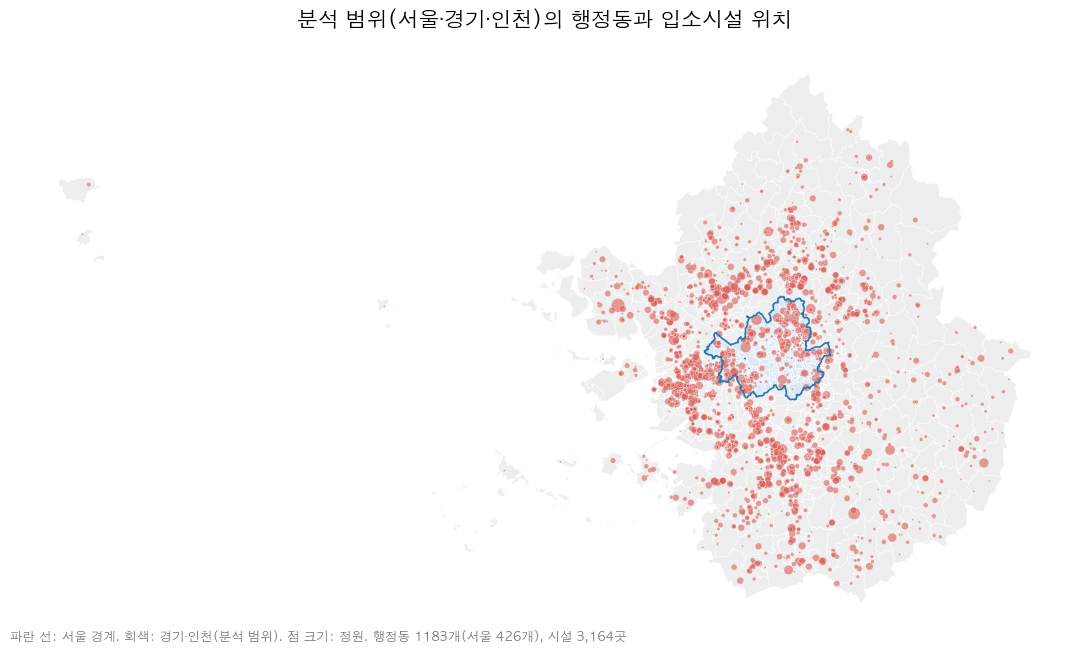

In [12]:
fig, ax = plt.subplots(figsize=(11, 10))
study_dong.loc[~study_dong["서울"]].plot(ax=ax, color="#EEEEEE", edgecolor="white", linewidth=0.4)
study_dong.loc[study_dong["서울"]].plot(ax=ax, color="#DCE8F4", edgecolor="white", linewidth=0.4)
gpd.GeoSeries([seoul_shape], crs=C.CRS).boundary.plot(ax=ax, color="#2878B5", linewidth=1.2)

in_area = facility.loc[facility["분석범위"]]
in_area.plot(
    ax=ax, markersize=in_area["정원"] / 4, color="#D95F59", alpha=0.6, edgecolor="white", linewidth=0.3
)
ax.set_title("분석 범위(서울·경기·인천)의 행정동과 입소시설 위치", fontsize=15, pad=14)
ax.set_axis_off()
ax.text(
    0, -0.02,
    f"파란 선: 서울 경계. 회색: 경기·인천(분석 범위). 점 크기: 정원. "
    f"행정동 {len(study_dong)}개(서울 {study_dong['서울'].sum()}개), 시설 {len(in_area):,}곳",
    transform=ax.transAxes, fontsize=9, color="#777777",
)
plt.tight_layout()
fig.savefig(C.OUTPUT_DIR / "행정동_시설_지도.png", dpi=200, bbox_inches="tight")
plt.show()

### 8. 재가(주야간보호) 층 사전 확인

후속 재가 층 분석에 필요한 주야간보호 정원이 시설 파일에 있는지 확인한다. `입소인원` 시트에 주야간보호(B03 재가노인복지시설, C03 재가장기요양기관) 행이 정원·현원과 함께 들어 있다.

In [13]:
daycare = (
    capacity.loc[capacity["기관유형코드"].isin(C.DAYCARE_CODES)]
    .merge(general[["장기요양기관코드", "시도"]], on="장기요양기관코드", how="inner")
)
assert daycare["정원"].notna().all()
daycare.loc[daycare["시도"].isin(C.SIDO_CODES.values())].groupby(["시도", "기관유형코드"]).agg(
    시설수=("장기요양기관코드", "nunique"), 정원=("정원", "sum"), 현원=("현원", "sum")
)

시설수        정원     현원
시도    기관유형코드                      
경기도   B03     830 31,210.00  23408
      C03     276  9,765.00   7682
서울특별시 B03     468 15,283.00  13362
      C03      30  1,064.00    878
인천광역시 B03     163  5,964.00   4367
      C03      76  2,773.00   2217

### 9. 시설 파일 점검 메모

In [14]:
# (1) 한 기관에 입소 유형 행이 둘 이상인 경우: 정원을 합산했다.
multi = capacity.loc[capacity["기관유형코드"].isin(C.RESIDENTIAL_CODES)].groupby("장기요양기관코드").filter(lambda g: len(g) > 1)
# (2) 인력현황에는 입소 유형으로 있으나 입소인원(정원) 행이 없는 기관
staff = pd.read_excel(C.FACILITY_FILE, sheet_name="인력현황", dtype={"장기요양기관코드": str})
staff_res = staff.loc[staff["기관유형코드"].isin(C.RESIDENTIAL_CODES)].merge(general[["장기요양기관코드", "시도"]], on="장기요양기관코드")
no_capacity = staff_res.loc[~staff_res["장기요양기관코드"].isin(capacity.loc[capacity["기관유형코드"].isin(C.RESIDENTIAL_CODES), "장기요양기관코드"])]
# (3) A01~A05 행 없이 치매전담형 공동생활가정(S41) 등만 있는 기관: 기존 정의대로 제외한다.
dementia_only = (
    capacity.loc[capacity["기관유형코드"].str.match(r"^[GMS]\d")]
    .loc[lambda d: ~d["장기요양기관코드"].isin(capacity.loc[capacity["기관유형코드"].isin(C.RESIDENTIAL_CODES), "장기요양기관코드"])]
    .merge(general[["장기요양기관코드", "시도"]], on="장기요양기관코드")
)
in_region = lambda d: d["시도"].isin(C.SIDO_CODES.values())
display(Markdown(
    f"- 입소 유형 행이 둘 이상인 기관: 전국 {multi['장기요양기관코드'].nunique()}곳, 서울·경기·인천 "
    f"{multi.merge(general[['장기요양기관코드', '시도']]).pipe(lambda d: d.loc[in_region(d), '장기요양기관코드'].nunique())}곳(정원 합산)\n"
    f"- 인력현황에만 입소 유형으로 있고 정원 자료가 없는 기관: 서울 {(no_capacity['시도'] == '서울특별시').sum()}곳, "
    f"서울·경기·인천 {in_region(no_capacity).sum()}곳 → 정원을 알 수 없어 제외\n"
    f"- 치매전담 유형만 있는 기관(주로 S41): 서울 {(dementia_only['시도'] == '서울특별시').sum()}곳·"
    f"{dementia_only.loc[dementia_only['시도'] == '서울특별시', '정원'].sum():,.0f}석, "
    f"서울·경기·인천 {in_region(dementia_only).sum()}곳 → 기존 정의(A01~A05)대로 제외"
))

- 입소 유형 행이 둘 이상인 기관: 전국 7곳, 서울·경기·인천 1곳(정원 합산)
- 인력현황에만 입소 유형으로 있고 정원 자료가 없는 기관: 서울 12곳, 서울·경기·인천 127곳 → 정원을 알 수 없어 제외
- 치매전담 유형만 있는 기관(주로 S41): 서울 3곳·23석, 서울·경기·인천 17곳 → 기존 정의(A01~A05)대로 제외

### 10. 검증 요약

In [15]:
seoul_facility = facility.loc[facility["시도"].eq("서울특별시")]
assert study_dong["서울"].sum() == 426
assert len(seoul_facility) == 485
assert seoul_facility["분석범위"].sum() + len(no_xy_seoul) == 485  # 좌표가 있는 서울 시설은 모두 범위 안

summary_sentence = (
    f"서울 {study_dong['서울'].sum()}개 행정동과 경기·인천 전체 "
    f"{(~study_dong['서울']).sum()}개 읍면동을 분석 범위로 두었다. 입소시설 "
    f"{len(facility):,}곳 중 {has_xy.sum():,}곳({has_xy.mean():.1%})의 좌표를 확보했으며, "
    f"분석 범위 안 시설은 {facility['분석범위'].sum():,}곳(서울 {seoul_facility['분석범위'].sum()}곳)이다."
)
display(Markdown(f"> {summary_sentence}"))
print(summary_sentence)

> 서울 426개 행정동과 경기·인천 전체 757개 읍면동을 분석 범위로 두었다. 입소시설 3,167곳 중 3,164곳(99.9%)의 좌표를 확보했으며, 분석 범위 안 시설은 3,164곳(서울 484곳)이다.

서울 426개 행정동과 경기·인천 전체 757개 읍면동을 분석 범위로 두었다. 입소시설 3,167곳 중 3,164곳(99.9%)의 좌표를 확보했으며, 분석 범위 안 시설은 3,164곳(서울 484곳)이다.


### 출처

- 행정동 경계: vuski/admdongkor `ver20240701` — https://github.com/vuski/admdongkor
- 행정안전부 주민등록 인구통계(연령별 인구현황, 전체읍면동): https://jumin.mois.go.kr/ageStatMonth.do
- 국민건강보험공단_장기요양기관 시설별 현황: https://www.data.go.kr/data/15124763/fileData.do
- 카카오 로컬 API(주소 검색): https://developers.kakao.com/docs/latest/ko/local/dev-guide#address-coord